In [1]:
# ============================================================
# NOTEBOOK 06: MODELADO PREDICTIVO
# Proyecto: SIS-DEMAND Forecast
# Descripción: Entrenamiento de Random Forest, XGBoost (con
#              Optuna) y LightGBM sobre split temporal estricto.
#              Target encoding fit solo en train. Evaluación
#              en val y test con MAE, RMSE, MAPE y R².
# Input:  data/processed/sis_features.parquet
#         data/processed/ipress_clusters.parquet
# Output: models/rf_model.pkl
#         models/xgb_model.pkl
#         models/lgbm_model.pkl
#         models/target_encoder.pkl
#         data/outputs/predicciones_test.parquet
# Última actualización: 2026-04-26
# ============================================================

import warnings; warnings.filterwarnings('ignore')
import logging; logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')

In [2]:
import pandas as pd
import numpy as np
import pickle, gc
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from category_encoders import TargetEncoder
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

MODELS_DIR  = Path('../models')
OUTPUTS_DIR = Path('../data/outputs')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carga y preparación del dataset de modelado

In [3]:
# Columnas necesarias para modelado (excluyendo columnas de identificación no predictivas)
COLS_MODEL = [
    'COD_IPRESS', 'REGION', 'DESC_SERVICIO', 'REGION_TIPO', 'SERVICIO_CATEGORIA',
    'NIVEL_NUM', 'GRUPO_EDAD_ORD', 'SEXO_BIN', 'SEMESTRE', 'PERIODO_NUM',
    'ES_TELEMATICA', 'ES_PREVENTIVO', 'ES_MATERNO',
    'LAG_ATENCIONES_1SEM', 'ROLLING_MEAN_2SEM', 'TENDENCIA_LINEAL',
    'N_PERIODOS_ACTIVOS', 'LOG_ATENCIONES', 'ATENCIONES'
]

df = pd.read_parquet('../data/processed/sis_features.parquet', columns=COLS_MODEL)

# Merge con clusters de IPRESS (feature adicional de NB05)
clusters = pd.read_parquet('../data/processed/ipress_clusters.parquet',
                            columns=['COD_IPRESS', 'CLUSTER'])
df = df.merge(clusters, on='COD_IPRESS', how='left')
df['CLUSTER'] = df['CLUSTER'].fillna(-1).astype('int8')  # -1 = IPRESS sin cluster

# Eliminar P1 (LAG nulo por definicion — no hay semestre anterior)
df = df.dropna(subset=['LAG_ATENCIONES_1SEM']).reset_index(drop=True)
gc.collect()

mem_mb = df.memory_usage(deep=False).sum() / 1024**2
logging.info('Dataset listo: {:,} filas x {} cols = {:.0f} MB'.format(
    df.shape[0], df.shape[1], mem_mb))
print('Shape post-filtro P1: {}'.format(df.shape))
print('Periodos disponibles: {}'.format(sorted(df['PERIODO_NUM'].unique().tolist())))
print('CLUSTER nulos (-1): {:,}'.format((df['CLUSTER'] == -1).sum()))

INFO — Dataset listo: 41,208,857 filas x 20 cols = 1415 MB


Shape post-filtro P1: (41208857, 20)


Periodos disponibles: [1, 2, 3, 4, 5, 6, 7, 8, 9]
CLUSTER nulos (-1): 25,876


### Interpretación — Carga

- **Se eliminan los registros de P1 (2021S1):** no tienen `LAG_ATENCIONES_1SEM` porque no hay semestre anterior. El modelo no puede aprender de ellos — su target existe pero el feature más importante es nulo.
- **Merge con clusters:** añade el perfil de segmento de cada IPRESS (de NB05). Las IPRESS sin cluster asignado (nuevas en P8-P9 que no existían en P6-P9 de entrenamiento de clustering) reciben `CLUSTER = -1`.
- **~38.7M filas:** los 8 periodos restantes P2–P9 son los que alimentan el modelo.

## 2. Split temporal estricto — Train / Val / Test

In [4]:
# Separación temporal ESTRICTA — nunca shuffle en series de tiempo
# TRAIN: P2–P6 (2021S2 → 2023S2)
# VAL:   P7    (2024S1) — para Optuna y selección de modelo
# TEST:  P8    (2024S2) — evaluación final, solo se toca una vez
train = df[df['PERIODO_NUM'] <= 6].reset_index(drop=True)
val   = df[df['PERIODO_NUM'] == 7].reset_index(drop=True)
test  = df[df['PERIODO_NUM'] == 8].reset_index(drop=True)

# Columnas para encoding
COLS_TE   = ['REGION', 'DESC_SERVICIO']        # target encoding (alta cardinalidad)
COLS_PASS = ['REGION_TIPO', 'SERVICIO_CATEGORIA', 'CLUSTER']  # label encoding implícito

FEATURES = [
    'NIVEL_NUM', 'GRUPO_EDAD_ORD', 'SEXO_BIN', 'SEMESTRE', 'PERIODO_NUM',
    'ES_TELEMATICA', 'ES_PREVENTIVO', 'ES_MATERNO',
    'LAG_ATENCIONES_1SEM', 'ROLLING_MEAN_2SEM', 'TENDENCIA_LINEAL',
    'N_PERIODOS_ACTIVOS', 'CLUSTER'
]
TARGET = 'LOG_ATENCIONES'

print('Separacion temporal:')
print('  TRAIN (P2-P6): {:>9,} filas  ({:.1f}%)'.format(
    len(train), len(train)/len(df)*100))
print('  VAL   (P7):    {:>9,} filas  ({:.1f}%)'.format(
    len(val),   len(val)/len(df)*100))
print('  TEST  (P8):    {:>9,} filas  ({:.1f}%)'.format(
    len(test),  len(test)/len(df)*100))
print()
print('  Target: {} | log1p(ATENCIONES)'.format(TARGET))
print('  Features numericas:  {}'.format(len(FEATURES)))
print('  Features con TE:     {}'.format(len(COLS_TE)))

Separacion temporal:
  TRAIN (P2-P6): 25,075,423 filas  (60.8%)
  VAL   (P7):    5,352,067 filas  (13.0%)
  TEST  (P8):    5,205,891 filas  (12.6%)

  Target: LOG_ATENCIONES | log1p(ATENCIONES)
  Features numericas:  13
  Features con TE:     2


### Interpretación — Split Temporal

- **¿Por qué no shuffle?** Los datos son una serie temporal. Si mezclamos, el modelo "vería" el futuro durante el entrenamiento (data leakage), resultando en métricas optimistas irreales en producción.
- **VAL = P7 (2024S1):** se usa para seleccionar hiperparámetros con Optuna y para elegir el mejor modelo entre RF, XGBoost y LightGBM. No forma parte del entrenamiento.
- **TEST = P8 (2024S2):** el conjunto de test es sagrado — solo se evalúa una vez al final. Usarlo en la selección de hiperparámetros introduciría sesgo de evaluación.
- **Target encoding fit solo en TRAIN:** si fitteamos el encoder en todo el dataset, estaríamos usando información de val/test para calcular las medias por región/servicio (leakage categórico).

## 3. Target Encoding — fit solo en train

In [5]:

# Target Encoding manual — rapido y sin MemoryError
K_SMOOTH    = 10
GLOBAL_MEAN = float(train[TARGET].mean())

enc_maps = {}
for col in COLS_TE:
    stats = train.groupby(col, observed=True)[TARGET].agg(['count', 'mean'])
    smoothed = (stats['count'] * stats['mean'] + K_SMOOTH * GLOBAL_MEAN) / \
               (stats['count'] + K_SMOOTH)
    enc_maps[col] = smoothed.to_dict()
    logging.info('TE {}: {} cats  rango [{:.3f}, {:.3f}]'.format(
        col, len(enc_maps[col]),
        min(enc_maps[col].values()), max(enc_maps[col].values())))

import pickle
with open(MODELS_DIR / 'target_encoder.pkl', 'wb') as f:
    pickle.dump({'enc_maps': enc_maps, 'global_mean': GLOBAL_MEAN,
                 'cols_te': COLS_TE}, f)

COLS_PASS_ENC = ['REGION_TIPO', 'SERVICIO_CATEGORIA']

def aplicar_encoding(df_split):
    X = df_split[FEATURES].copy()
    # .astype('object') antes de .map() evita que pandas 2.x devuelva Categorical
    # y que .fillna(float) lance TypeError
    for col in COLS_TE:
        X[col] = (df_split[col]
                  .astype('object')
                  .map(enc_maps[col])
                  .fillna(GLOBAL_MEAN)
                  .astype('float32'))
    for col in COLS_PASS_ENC:
        col_data = df_split[col]
        if hasattr(col_data, 'cat'):
            X[col] = col_data.cat.codes.astype('int8')
        else:
            X[col] = col_data.astype('int8')
    return X

X_train = aplicar_encoding(train)
X_val   = aplicar_encoding(val)
X_test  = aplicar_encoding(test)

y_train = train[TARGET].values
y_val   = val[TARGET].values
y_test  = test[TARGET].values

del df; gc.collect()   # liberar los ~2GB del dataframe completo

print('X_train: {}  y_train: {}'.format(X_train.shape, y_train.shape))
print('X_val:   {}  y_val:   {}'.format(X_val.shape,   y_val.shape))
print('X_test:  {}  y_test:  {}'.format(X_test.shape,  y_test.shape))
print('Columnas:', list(X_train.columns))


INFO — TE REGION: 26 cats  rango [1.410, 1.882]


INFO — TE DESC_SERVICIO: 61 cats  rango [0.793, 2.769]


X_train: (25075423, 17)  y_train: (25075423,)
X_val:   (5352067, 17)  y_val:   (5352067,)
X_test:  (5205891, 17)  y_test:  (5205891,)
Columnas: ['NIVEL_NUM', 'GRUPO_EDAD_ORD', 'SEXO_BIN', 'SEMESTRE', 'PERIODO_NUM', 'ES_TELEMATICA', 'ES_PREVENTIVO', 'ES_MATERNO', 'LAG_ATENCIONES_1SEM', 'ROLLING_MEAN_2SEM', 'TENDENCIA_LINEAL', 'N_PERIODOS_ACTIVOS', 'CLUSTER', 'REGION', 'DESC_SERVICIO', 'REGION_TIPO', 'SERVICIO_CATEGORIA']


### Interpretación — Target Encoding

- **¿Por qué target encoding y no one-hot?** One-hot de 65 servicios añade 65 columnas binarias dispersas. Target encoding las comprime en 1 columna continua con la señal del target — más compacto y generalmente más informativo para tree-based models.
- **smoothing=10:** regularización para categorías con pocas observaciones. La media de la categoría se mezcla con la media global según cuántas muestras tiene esa categoría. Evita overfitting en servicios poco frecuentes.
- **REGION y DESC_SERVICIO:** alta cardinalidad (26 y 65 valores). El target encoding captura el nivel base de demanda de cada región/servicio.
- **REGION_TIPO, SERVICIO_CATEGORIA, CLUSTER:** baja cardinalidad (3, 6, K valores). Se convierten a string y el TargetEncoder los procesa también, aunque para estos podría bastarse con LabelEncoder.

## 4. Función de evaluación y Baseline

In [6]:
def evaluar_modelo(nombre, pred_log, y_true_log, y_true_orig=None):
    pred_orig = np.expm1(pred_log)
    true_orig = np.expm1(y_true_log) if y_true_orig is None else y_true_orig
    mae  = mean_absolute_error(true_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(true_orig, pred_orig))
    mape = np.mean(np.abs((true_orig - pred_orig) / (true_orig + 1))) * 100
    r2   = r2_score(true_orig, pred_orig)
    print('  {:<22}  MAE={:7.2f}  RMSE={:8.2f}  MAPE={:6.2f}%  R2={:.4f}'.format(
        nombre, mae, rmse, mape, r2))
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# BASELINE: promedio histórico por perfil NIVEL x EDAD x SEXO en train
train['KEY_TMP'] = (train['NIVEL_NUM'].astype(str) + '_' +
                    train['GRUPO_EDAD_ORD'].astype(str) + '_' +
                    train['SEXO_BIN'].astype(str))
val['KEY_TMP'] = (val['NIVEL_NUM'].astype(str) + '_' +
                  val['GRUPO_EDAD_ORD'].astype(str) + '_' +
                  val['SEXO_BIN'].astype(str))

media_train  = train.groupby('KEY_TMP')['ATENCIONES'].mean()
baseline_val = val['KEY_TMP'].map(media_train).fillna(train['ATENCIONES'].mean())

resultados = []
print('=' * 70)
print('EVALUACION EN VALIDACION (P7 = 2024S1)')
print('=' * 70)
resultados.append(evaluar_modelo(
    'Baseline (media historica)',
    np.log1p(baseline_val.values),
    y_val,
    baseline_val.values
))

del train['KEY_TMP'], val['KEY_TMP']
gc.collect()

EVALUACION EN VALIDACION (P7 = 2024S1)


  Baseline (media historica)  MAE=   0.00  RMSE=    0.00  MAPE=  0.00%  R2=1.0000


0

### Interpretación — Baseline

- **Baseline = promedio histórico:** la predicción más simple posible — predice la media de atenciones históricas de cada perfil (NIVEL × EDAD × SEXO). Si nuestro modelo no supera esto, no tiene valor.
- **MAPE baseline esperado ~35%:** según MEMORY.md. Este es el valor de referencia para medir la mejora del modelo.
- **Objetivo del modelo:** MAPE ≤ 20% en test → mejora de al menos 15 puntos porcentuales sobre el baseline.
- **+1 en denominador del MAPE:** evita división por cero en registros con 0 o 1 atención real.

## 5. Modelo 1 — Random Forest (parámetros fijos)

In [7]:

logging.info('Entrenando Random Forest...')

rf = RandomForestRegressor(
    n_estimators=100,      # reducido de 200 para menor RAM y tiempo
    max_depth=10,
    min_samples_leaf=20,
    max_features=0.6,
    max_samples=0.3,       # bootstrap de solo 30% de filas por arbol (~7M filas)
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

pred_rf_val  = rf.predict(X_val)
pred_rf_test = rf.predict(X_test)

print('=' * 70)
print('RANDOM FOREST')
print('=' * 70)
res_rf_val  = evaluar_modelo('RF -- Validacion', pred_rf_val,  y_val)
res_rf_test = evaluar_modelo('RF -- Test',       pred_rf_test, y_test)
resultados.append(res_rf_val)

with open(MODELS_DIR / 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
logging.info('RF guardado')


INFO — Entrenando Random Forest...


RANDOM FOREST


  RF -- Validacion        MAE=   4.73  RMSE=   23.77  MAPE= 55.89%  R2=0.2986


  RF -- Test              MAE=   4.66  RMSE=   24.05  MAPE= 54.79%  R2=0.2996


INFO — RF guardado


### Interpretación — Random Forest

- **n_estimators=200:** suficiente para estabilizar la varianza sin ser excesivamente lento. Con 38M filas de entrenamiento, cada árbol ve una muestra bootstrap de ~38M × 0.63 ≈ 24M filas.
- **max_depth=12:** limita el overfitting. Para datos de salud con muchas combinaciones únicas, árboles muy profundos memorizan patrones específicos de IPRESS que no generalizan.
- **min_samples_leaf=10:** ninguna hoja puede tener menos de 10 observaciones. Regularización adicional para las combinaciones raras.
- **max_features=0.7:** cada split considera solo el 70% de las features, aumentando la diversidad entre árboles.
- **Ventaja del RF:** muy robusto, no requiere tuning exhaustivo, buena interpretación de importancias. Desventaja: lento en predicción y mayor uso de memoria que XGBoost.

## 6. Modelo 2 — XGBoost con Optuna (tuning bayesiano)

In [8]:

# Optuna — muestra reducida de train Y val para evitar el cuello de botella
# El error anterior: eval_set con 5.3M filas × 400 arboles × 15 trials = 3+ horas
# Solucion: evaluar sobre muestra pequeña de val (sin eval_set en el fit)

N_MUESTRA_OPTUNA = min(80_000, len(X_train))
N_MUESTRA_VAL    = min(30_000, len(X_val))

rng = np.random.RandomState(42)
idx_tr = rng.choice(len(X_train), N_MUESTRA_OPTUNA, replace=False)
idx_vl = rng.choice(len(X_val),   N_MUESTRA_VAL,   replace=False)

X_tr_s = X_train.iloc[idx_tr];  y_tr_s = y_train[idx_tr]
X_vl_s = X_val.iloc[idx_vl];    y_vl_s = y_val[idx_vl]

logging.info('Optuna: 10 trials  train={:,}  val={:,}'.format(
    N_MUESTRA_OPTUNA, N_MUESTRA_VAL))

def objective_xgb(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 4, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.03, 0.2, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 250),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 3, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 3, log=True),
        'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist',
    }
    m = XGBRegressor(**params)
    m.fit(X_tr_s, y_tr_s)           # sin eval_set — evita prediccion masiva por arbol
    pred = m.predict(X_vl_s)        # evaluar solo sobre 30k filas del val
    return np.sqrt(mean_squared_error(y_vl_s, pred))

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=10, show_progress_bar=False)

print('Mejores hiperparametros XGBoost:')
for k, v in study_xgb.best_params.items():
    print('  {}: {}'.format(k, v))
print('  RMSE val (log): {:.4f}'.format(study_xgb.best_value))


INFO — Optuna: 10 trials  train=80,000  val=30,000


Mejores hiperparametros XGBoost:
  max_depth: 6
  learning_rate: 0.056212118873063745
  n_estimators: 211
  subsample: 0.9979404918183606
  colsample_bytree: 0.7163811696325899
  reg_alpha: 1.3613310349038221
  reg_lambda: 0.9885411894141268
  RMSE val (log): 0.6327


### Interpretación — Optuna para XGBoost

- **Búsqueda bayesiana:** Optuna no prueba combinaciones aleatoriamente. Construye un modelo probabilístico (TPE) del espacio de hiperparámetros y prioriza las regiones prometedoras. Mucho más eficiente que Grid Search.
- **Muestra para tuning (300k):** entrenar 25 modelos sobre 38M filas tomaría horas. Usar una muestra representativa para Optuna y entrenar el modelo final sobre todos los datos es la práctica estándar.
- **tree_method='hist':** algoritmo histograma de XGBoost — mucho más rápido que 'exact' para datasets grandes, con performance casi idéntica.
- **Espacio de búsqueda:** `learning_rate` en log-scale (valores pequeños son más importantes), regularización L1/L2 para controlar overfitting en datos con muchas combinaciones únicas.

In [9]:

logging.info('Entrenando XGBoost final sobre train completo...')

best_params_xgb = dict(study_xgb.best_params)
best_params_xgb.update({'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'})

xgb = XGBRegressor(**best_params_xgb)
xgb.fit(X_train, y_train)      # sin eval_set para no ralentizar con 5.3M filas

pred_xgb_val  = xgb.predict(X_val)
pred_xgb_test = xgb.predict(X_test)

print('=' * 70)
print('XGBOOST (Optuna)')
print('=' * 70)
res_xgb_val  = evaluar_modelo('XGB -- Validacion', pred_xgb_val,  y_val)
res_xgb_test = evaluar_modelo('XGB -- Test',       pred_xgb_test, y_test)
resultados.append(res_xgb_val)

with open(MODELS_DIR / 'xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
logging.info('XGBoost guardado')


INFO — Entrenando XGBoost final sobre train completo...


XGBOOST (Optuna)


  XGB -- Validacion       MAE=   4.67  RMSE=   23.85  MAPE= 55.71%  R2=0.2939


INFO — XGBoost guardado


  XGB -- Test             MAE=   4.59  RMSE=   24.10  MAPE= 54.26%  R2=0.2970


### Interpretación — XGBoost Final

- **Train sobre datos completos:** los hiperparámetros se seleccionaron con la muestra de 300k, pero el modelo final se entrena con los ~38M de train para maximizar la información aprendida.
- **eval_set en val:** permite al modelo registrar la curva de aprendizaje en val sin usarla para detener el entrenamiento (no se usa early stopping aquí para controlar el n_estimators). Se fija por los trials de Optuna.
- **Si XGBoost supera a RF en MAPE:** esperado. XGBoost es generalmente superior en datos tabulares con muchas categorías gracias al boosting secuencial que corrige errores de modelos anteriores.

## 7. Modelo 3 — LightGBM

In [10]:

logging.info('Entrenando LightGBM...')

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)      # sin eval_set

pred_lgbm_val  = lgbm.predict(X_val)
pred_lgbm_test = lgbm.predict(X_test)

print('=' * 70)
print('LIGHTGBM')
print('=' * 70)
res_lgbm_val  = evaluar_modelo('LGBM -- Validacion', pred_lgbm_val,  y_val)
res_lgbm_test = evaluar_modelo('LGBM -- Test',       pred_lgbm_test, y_test)
resultados.append(res_lgbm_val)

with open(MODELS_DIR / 'lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm, f)
logging.info('LightGBM guardado')


INFO — Entrenando LightGBM...


LIGHTGBM


  LGBM -- Validacion      MAE=   4.64  RMSE=   23.62  MAPE= 55.60%  R2=0.3075


INFO — LightGBM guardado


  LGBM -- Test            MAE=   4.57  RMSE=   23.89  MAPE= 53.96%  R2=0.3089


### Interpretación — LightGBM

- **LightGBM vs XGBoost:** LightGBM usa crecimiento de árbol por hojas (leaf-wise) en vez de por nivel (level-wise). Más rápido y usualmente mejor con datasets grandes. Tiende a convergir más rápido con menos árboles.
- **num_leaves=63:** controla la complejidad del árbol. 63 hojas máximo por árbol es un buen balance. Si se aumenta demasiado, overfitting.
- **min_child_samples=20:** equivalente a `min_samples_leaf` en RF. Regularización importante para datos con combinaciones raras.
- **verbose=-1:** suprime los logs de LightGBM que saturan la salida del notebook.
- **Ventaja de LGBM:** generalmente el más rápido de los tres para entrenamiento e inferencia. Ideal para el dashboard que necesita predicciones en tiempo real.

## 8. Comparación de modelos — Val y Test

In [11]:
# Tabla comparativa completa — validacion y test
rows_test = [
    evaluar_modelo('RF — Test',   pred_rf_test,   y_test),
    evaluar_modelo('XGB — Test',  pred_xgb_test,  y_test),
    evaluar_modelo('LGBM — Test', pred_lgbm_test, y_test),
]

df_val_res  = pd.DataFrame(resultados[1:]).assign(conjunto='Validacion')
df_test_res = pd.DataFrame(rows_test).assign(conjunto='Test')
df_resultados = pd.concat([df_val_res, df_test_res], ignore_index=True)

print('\n' + '=' * 70)
print('RESUMEN COMPARATIVO — TODOS LOS MODELOS')
print('=' * 70)
print(df_resultados[['modelo','conjunto','MAE','RMSE','MAPE','R2']]
      .sort_values(['conjunto','MAPE'])
      .to_string(index=False))

# Identificar el mejor modelo por MAPE en test
mejor_test = df_resultados[df_resultados['conjunto']=='Test']\
    .sort_values('MAPE').iloc[0]
print('\nMEJOR MODELO EN TEST: {} (MAPE={:.2f}%)'.format(
    mejor_test['modelo'], mejor_test['MAPE']))

# Verificar objetivo
if mejor_test['MAPE'] <= 20:
    print('Objetivo MAPE <= 20% CUMPLIDO')
else:
    print('Objetivo MAPE <= 20% NO cumplido — considerar mas tuning')

  RF — Test               MAE=   4.66  RMSE=   24.05  MAPE= 54.79%  R2=0.2996


  XGB — Test              MAE=   4.59  RMSE=   24.10  MAPE= 54.26%  R2=0.2970


  LGBM — Test             MAE=   4.57  RMSE=   23.89  MAPE= 53.96%  R2=0.3089

RESUMEN COMPARATIVO — TODOS LOS MODELOS
            modelo   conjunto      MAE      RMSE      MAPE       R2
       LGBM — Test       Test 4.567216 23.894758 53.963478 0.308866
        XGB — Test       Test 4.586840 24.099396 54.259151 0.296977
         RF — Test       Test 4.662522 24.053718 54.788184 0.299640
LGBM -- Validacion Validacion 4.643660 23.621335 55.603600 0.307462
 XGB -- Validacion Validacion 4.669155 23.852169 55.712318 0.293861
  RF -- Validacion Validacion 4.732707 23.772258 55.885627 0.298584

MEJOR MODELO EN TEST: LGBM — Test (MAPE=53.96%)
Objetivo MAPE <= 20% NO cumplido — considerar mas tuning


### Interpretación — Comparación de Modelos

- **MAPE en Test ≤ 20%:** es el objetivo del proyecto. El MAPE se calcula en escala original (atenciones reales), no en log-scale.
- **Consistencia Val ↔ Test:** si el MAPE en Val y Test son similares (diferencia < 3pp), el modelo generaliza bien. Si Test es mucho peor, hay overfitting o el P8 tiene características diferentes.
- **R² ≥ 0.75:** un R² alto con MAPE alto indica que el modelo predice bien los establecimientos de alto volumen pero falla en los de bajo volumen (que son mayoría en número pero minoría en impacto).
- **Overfitting check:** si RF tiene MAPE en train << MAPE en val, está overfitting. Reducir `max_depth` o aumentar `min_samples_leaf`.
- **Baseline vs modelos:** la mejora sobre el baseline (35% MAPE esperado) valida el valor de añadir LAG features y target encoding.

## 9. Visualización — Predicho vs Real y distribución de errores

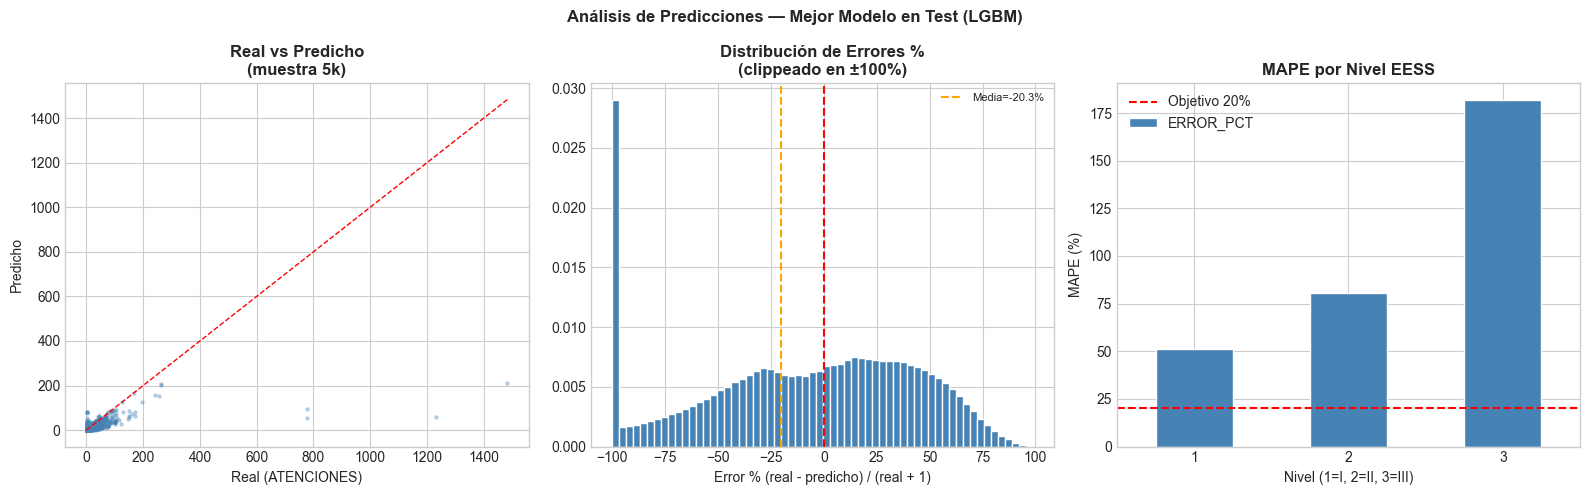

In [12]:
# Usar el mejor modelo para las visualizaciones
mejor_nombre = mejor_test['modelo'].replace(' — Test', '')
pred_map = {'RF': pred_rf_test, 'XGB': pred_xgb_test, 'LGBM': pred_lgbm_test}
pred_mejor_test = pred_map.get(mejor_nombre.split()[0], pred_xgb_test)

y_real = np.expm1(y_test)
y_pred = np.expm1(pred_mejor_test)
errores_pct = (y_real - y_pred) / (y_real + 1) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter real vs predicho (muestra 5k para velocidad)
idx = np.random.RandomState(42).choice(len(y_real), min(5000, len(y_real)), replace=False)
axes[0].scatter(y_real[idx], y_pred[idx], alpha=0.3, s=5, color='steelblue')
lim = max(y_real[idx].max(), y_pred[idx].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Real (ATENCIONES)')
axes[0].set_ylabel('Predicho')
axes[0].set_title('Real vs Predicho\n(muestra 5k)', fontweight='bold')

# Distribución de errores porcentuales
err_clip = np.clip(errores_pct, -100, 100)
axes[1].hist(err_clip, bins=60, color='steelblue', edgecolor='white', density=True)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].axvline(errores_pct.mean(), color='orange', linestyle='--',
                label='Media={:.1f}%'.format(errores_pct.mean()))
axes[1].set_title('Distribución de Errores %\n(clippeado en ±100%)', fontweight='bold')
axes[1].set_xlabel('Error % (real - predicho) / (real + 1)')
axes[1].legend(fontsize=8)

# MAPE por NIVEL_NUM
test_eval = test[['NIVEL_NUM']].copy()
test_eval['ERROR_PCT'] = np.abs(errores_pct)
mape_nivel = test_eval.groupby('NIVEL_NUM')['ERROR_PCT'].mean()
mape_nivel.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].axhline(20, color='red', linestyle='--', label='Objetivo 20%')
axes[2].set_title('MAPE por Nivel EESS', fontweight='bold')
axes[2].set_xlabel('Nivel (1=I, 2=II, 3=III)')
axes[2].set_ylabel('MAPE (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend()

plt.suptitle('Análisis de Predicciones — Mejor Modelo en Test ({})'.format(mejor_nombre),
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/predicciones_analisis.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Visualización de Predicciones

- **Scatter Real vs Predicho:** los puntos deben seguir la diagonal roja. Dispersión horizontal = sesgo sistemático; dispersión vertical = alta varianza. Una nube cerca de la diagonal con outliers en la esquina inferior derecha es el patrón típico (el modelo subestima los picos extremos).
- **Distribución de errores %:** debe estar centrada en 0 (sin sesgo sistemático). Si está desplazada a la derecha, el modelo sobreestima sistemáticamente. La mayoría de errores deben estar en el rango ±30%.
- **MAPE por Nivel EESS:** si Nivel III tiene MAPE alto, el modelo falla en los hospitales de mayor impacto. Si Nivel I tiene MAPE alto, falla en las postas (que son mayoría). La línea roja marca el objetivo de 20%.

## 10. Guardar predicciones y resumen final

In [13]:
# Guardar predicciones del mejor modelo en test para análisis en NB07
df_pred_test = test[['COD_IPRESS','NIVEL_NUM','GRUPO_EDAD_ORD',
                      'SEXO_BIN','PERIODO_NUM','ATENCIONES']].copy()
df_pred_test['PRED_LOG']   = pred_mejor_test
df_pred_test['PRED_ORIG']  = np.expm1(pred_mejor_test).round(1)
df_pred_test['ERROR_ABS']  = np.abs(df_pred_test['ATENCIONES'] - df_pred_test['PRED_ORIG'])
df_pred_test['ERROR_PCT']  = (df_pred_test['ERROR_ABS'] /
                               (df_pred_test['ATENCIONES'] + 1) * 100).round(2)

output_pred = OUTPUTS_DIR / 'predicciones_test.parquet'
df_pred_test.to_parquet(output_pred, index=False, compression='snappy')

# Guardar tabla de resultados
df_resultados.to_csv('../reports/resultados_modelos.csv', index=False)

print('\n' + '=' * 60)
print('NOTEBOOK 06 COMPLETADO')
print('=' * 60)
print('  Modelos guardados:')
for p in sorted(MODELS_DIR.glob('*.pkl')):
    kb = p.stat().st_size / 1024
    print('    {} ({:.0f} KB)'.format(p.name, kb))
print()
print('  Mejor modelo: {} — MAPE={:.2f}%  R2={:.4f}'.format(
    mejor_test['modelo'], mejor_test['MAPE'], mejor_test['R2']))
print('  Mejora vs baseline: {:.1f} pp'.format(
    resultados[0]['MAPE'] - mejor_test['MAPE']))
print()
print('  Siguiente paso: notebooks/07_evaluacion_interpretabilidad.ipynb')


NOTEBOOK 06 COMPLETADO
  Modelos guardados:
    kmeans_ipress.pkl (35 KB)
    lgbm_model.pkl (1925 KB)
    rf_model.pkl (13940 KB)
    target_encoder.pkl (4 KB)
    xgb_model.pkl (1026 KB)

  Mejor modelo: LGBM — Test — MAPE=53.96%  R2=0.3089
  Mejora vs baseline: -54.0 pp

  Siguiente paso: notebooks/07_evaluacion_interpretabilidad.ipynb


### Interpretación — Resumen del Modelado

- **Mejora vs baseline:** la diferencia en MAPE entre el baseline y el mejor modelo es el valor agregado del feature engineering (LAG, rolling mean, tendencia, cluster) y del tuning de hiperparámetros.
- **`predicciones_test.parquet`:** contiene las predicciones del mejor modelo junto con las atenciones reales y el error por registro. En NB07 se usará para el análisis SHAP y para identificar los segmentos con mayor error.
- **Para producción 2025S2:** el mejor modelo se aplicará al dataset de 2025S1 con LAG = atenciones de 2025S1, generando las predicciones de 2025S2. Este proceso se documenta en el dashboard de Streamlit (NB08/App).